    name  membership_months   age  weight  calories_burn  workout_hours
0  Arjun                  3  21.0    70.0          300.0            1.5
1   Neha                  6  25.0    60.0          450.0            2.0
2   Ravi                 12   NaN    85.0          500.0            NaN
3  Pooja                  4  23.0     NaN          200.0            1.0
4  Vikas                  8  27.0    78.0            NaN            2.5
membership_months
3     1
6     1
12    1
4     1
8     1
Name: count, dtype: int64
    name  membership_months   age  weight  calories_burn  workout_hours
0  Arjun                  3  21.0   70.00          300.0           1.50
1   Neha                  6  25.0   60.00          450.0           2.00
2   Ravi                 12  24.0   85.00          500.0           1.75
3  Pooja                  4  23.0   73.25          200.0           1.00
4  Vikas                  8  27.0   78.00          362.5           2.50
Upper bound: 743.75
Lower bound: -6.25
    name  mem

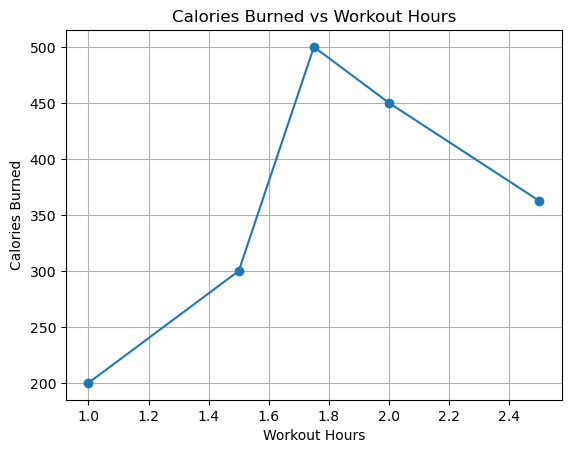

Correlation between calories burned and workout hours: 0.5977292194465816


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# New dataset
d = {
    "name": ["Arjun", "Neha", "Ravi", "Pooja", "Vikas"],
    "membership_months": [3, 6, 12, 4, 8],
    "age": [21, 25, np.nan, 23, 27],
    "weight": [70, 60, 85, np.nan, 78],
    "calories_burn": [300, 450, 500, 200, np.nan],
    "workout_hours": [1.5, 2, np.nan, 1, 2.5]
}

df = pd.DataFrame(d)
print(df)

# Number of members by membership duration
print(df["membership_months"].value_counts())

# Fill missing values
df_filled = df.fillna(df.mean(numeric_only=True))
print(df_filled)


# Detect outliers using IQR
q1 = df["calories_burn"].quantile(0.25)
q3 = df["calories_burn"].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

print("Upper bound:", upper)
print("Lower bound:", lower)

df = df[(df["calories_burn"] >= lower) & (df["calories_burn"] <= upper)]
print(df)


# Z-score outlier detection
z_calories = np.abs((df["calories_burn"] - df["calories_burn"].mean()) / df["calories_burn"].std())
z_hours = np.abs((df["workout_hours"] - df["workout_hours"].mean()) / df["workout_hours"].std())

print("Outliers in calories burned:")
print(df["calories_burn"][z_calories > 3])

print("Outliers in workout hours:")
print(df["workout_hours"][z_hours > 3])


# Sorting values
df_sorted = df_filled.sort_values("workout_hours")

# Line graph: Calories Burned vs Workout Hours
plt.plot(df_sorted["workout_hours"], df_sorted["calories_burn"], marker='o')
plt.xlabel("Workout Hours")
plt.ylabel("Calories Burned")
plt.title("Calories Burned vs Workout Hours")
plt.grid(True)
plt.show()


# Correlation
correlation = df_filled["calories_burn"].corr(df_filled["workout_hours"])
print("Correlation between calories burned and workout hours:", correlation)